In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for plots
sns.set(style='whitegrid')

In [2]:
# Read data from Excel files with absolute paths
nike = pd.read_excel(r'D:\SportBrands_FinancialAnalysis\data\nike_financials.xlsx')
adidas = pd.read_excel(r'D:\SportBrands_FinancialAnalysis\data\adidas_financials.xlsx')

print("Nike data preview:")
print(nike.head())

print("\nAdidas data preview:")
print(adidas.head())

Nike data preview:
   Years  Revenue（Million USD）  EPS(USD)  ROE(%)
0   2021                 44538      3.56    48.8
1   2022                 46710      3.75    46.5
2   2023                 51217      3.23    31.5
3   2024                 51362      3.73    34.9
4   2025                 46309      2.16    20.2

Adidas data preview:
   Years  Revenue(Million USD)  EPS(USD)  ROE(%)
0   2021                 25056      8.81    28.1
1   2022                 23637      1.31    12.3
2   2023                 23355     -0.73    -1.6
3   2024                 25578      4.58    14.0
4   2025                 27044      8.13    23.2


In [3]:
# Rename columns consistently
nike.columns = ['Year', 'Revenue', 'EPS', 'ROE']
adidas.columns = ['Year', 'Revenue', 'EPS', 'ROE']

# Define years to keep
years = [2021, 2022, 2023, 2024, 2025]

# Filter data for specified years
nike = nike[nike['Year'].isin(years)].reset_index(drop=True)
adidas = adidas[adidas['Year'].isin(years)].reset_index(drop=True)

# Check missing values
print("Nike missing values:")
print(nike.isnull().sum())

print("Adidas missing values:")
print(adidas.isnull().sum())

Nike missing values:
Year       0
Revenue    0
EPS        0
ROE        0
dtype: int64
Adidas missing values:
Year       0
Revenue    0
EPS        0
ROE        0
dtype: int64


In [4]:
nike['Revenue_Growth'] = nike['Revenue'].pct_change() * 100
adidas['Revenue_Growth'] = adidas['Revenue'].pct_change() * 100

print("Nike Revenue Growth (%):")
print(nike[['Year', 'Revenue_Growth']])

print("Adidas Revenue Growth (%):")
print(adidas[['Year', 'Revenue_Growth']])

Nike Revenue Growth (%):
   Year  Revenue_Growth
0  2021             NaN
1  2022        4.876734
2  2023        9.648897
3  2024        0.283109
4  2025       -9.838013
Adidas Revenue Growth (%):
   Year  Revenue_Growth
0  2021             NaN
1  2022       -5.663314
2  2023       -1.193045
3  2024        9.518304
4  2025        5.731488


In [5]:
nike['Brand'] = 'Nike'
adidas['Brand'] = 'Adidas'

combined_df = pd.concat([nike, adidas], ignore_index=True)

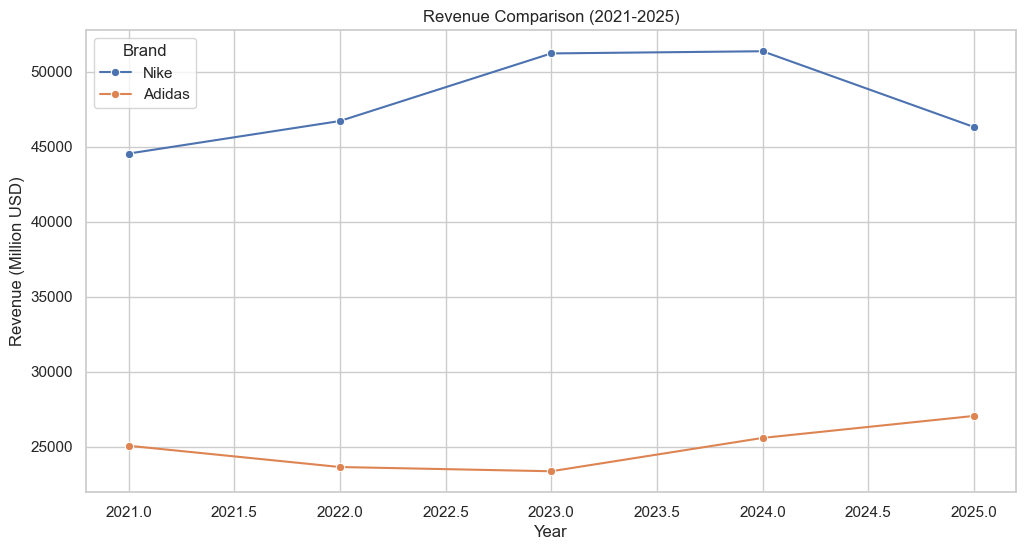

In [6]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_df, x='Year', y='Revenue', hue='Brand', marker='o')
plt.title('Revenue Comparison (2021-2025)')
plt.ylabel('Revenue (Million USD)')
plt.grid(True)
plt.show()

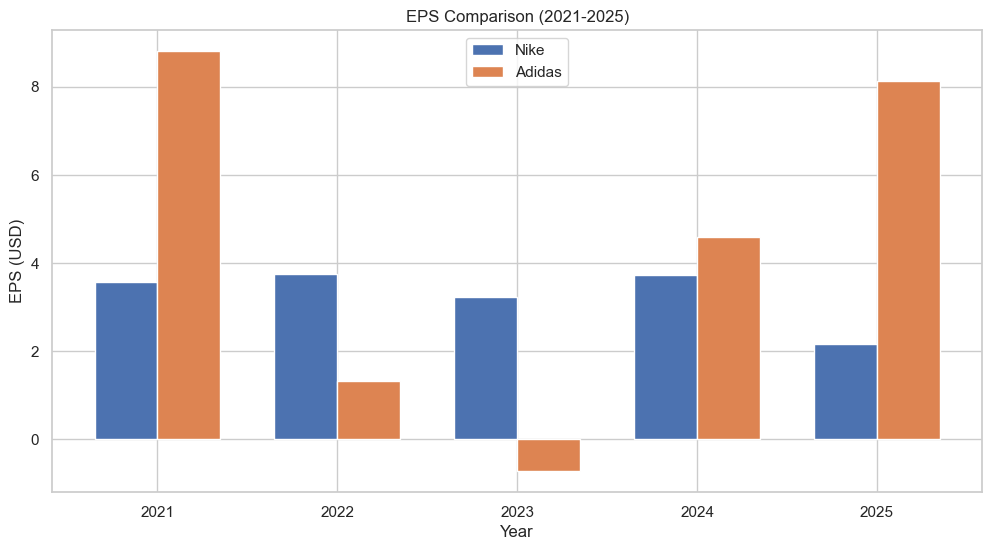

In [7]:
import numpy as np

years = nike['Year'].tolist()
x = np.arange(len(years))
bar_width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - bar_width/2, nike['EPS'], width=bar_width, label='Nike')
plt.bar(x + bar_width/2, adidas['EPS'], width=bar_width, label='Adidas')
plt.xticks(x, years)
plt.title('EPS Comparison (2021-2025)')
plt.xlabel('Year')
plt.ylabel('EPS (USD)')
plt.legend()
plt.show()

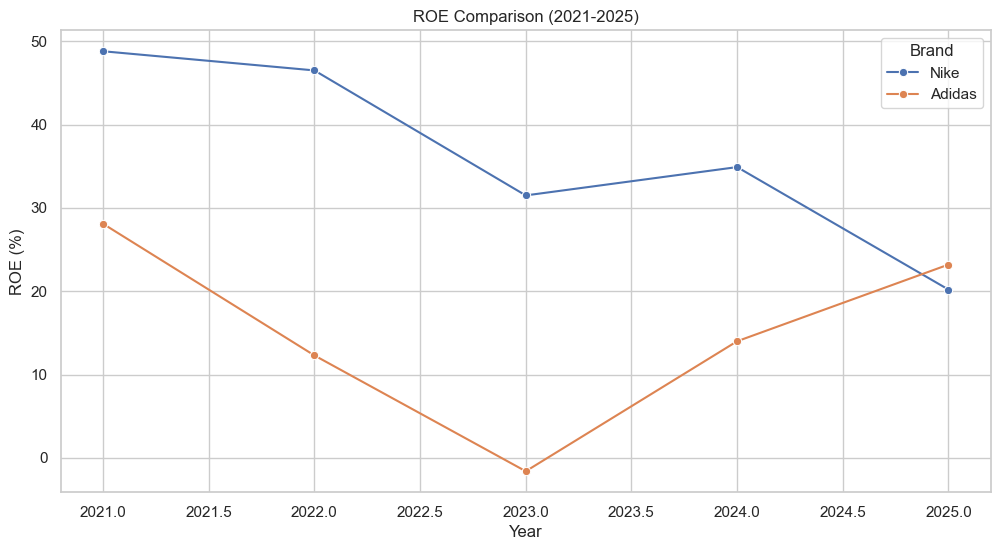

In [8]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_df, x='Year', y='ROE', hue='Brand', marker='o')
plt.title('ROE Comparison (2021-2025)')
plt.ylabel('ROE (%)')
plt.grid(True)
plt.show()

In [9]:
summary = combined_df.groupby('Brand')[['Revenue', 'EPS', 'ROE']].mean()
print("Average Financial Metrics (2021-2025):")
print(summary)

Average Financial Metrics (2021-2025):
        Revenue    EPS    ROE
Brand                        
Adidas  24934.0  4.420  15.20
Nike    48027.2  3.286  36.38


## Data Analysis Conclusions

- Both Nike and Adidas showed a growth trend in revenue from 2021 to 2025, with Nike having overall higher revenue.  
- Regarding EPS, Nike remained relatively stable, while Adidas experienced larger fluctuations and reported a negative EPS in 2023.  
- ROE indicates that Nike provided higher and more stable returns to shareholders compared to Adidas.